# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Melanie Martinez Macias"            # Tu nombre completo
MATRICULA = "82418"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "migracion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Melanie Martinez Macias
Matrícula: 82418
Dataset asignado: migracion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\melan\Documents\big data\examen1Parcial\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: migracion
Descripcion: Numero total de inmigrantes internacionales residiendo en el pais (personas)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,1990,57686,Asia
1,Afghanistan,AFG,1995,71522,Asia
2,Afghanistan,AFG,2000,75917,Asia
3,Afghanistan,AFG,2005,87314,Asia
4,Afghanistan,AFG,2010,102276,Asia
5,Afghanistan,AFG,2015,339432,Asia
6,Afghanistan,AFG,2020,144098,Asia
7,Afghanistan,AFG,2024,98110,Asia
8,Africa,OWID_AFR,1990,16176915,NaN
9,Africa,OWID_AFR,1995,16653698,NaN


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(2144, 5)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2144 entries, 0 to 2143
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   entity       2144 non-null   str  
 1   code         1960 non-null   str  
 2   year         2144 non-null   int64
 3   valor        2144 non-null   int64
 4   owid_region  1824 non-null   str  
dtypes: int64(2), str(3)
memory usage: 83.9 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    2.144000e+03
mean     4.987920e+06
std      1.998549e+07
min      1.080000e+02
25%      3.905450e+04
50%      2.187635e+05
75%      1.420072e+06
max      3.040218e+08
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           184
year             0
valor            0
owid_region    320
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?
pues que el code y owid_region tienen valores nulos mientras que entity.year y valor estan completas sin nulos y eso puede ser porque code no aplica para registros que representan regiones o agrupaciones y owid chance no esta definida para todas las etidades. y valor es una variable nimerica con un rango amplio por lo que representa una maginitud como poblacion y no como porcentaje



## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [10]:
# Pregunta 1
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull()]

num_paises = df_paises["entity"].nunique()
print("Número de países reales:", num_paises)

top_10_mayor = df_paises.sort_values("valor", ascending=False).head(10)
top_10_menor = df_paises.sort_values("valor", ascending=True).head(10)

print("Top 10 con mayor valor:")
print(top_10_mayor[["entity", "year", "valor"]])

print("\nTop 10 con menor valor:")
print(top_10_menor[["entity", "year", "valor"]])


Número de países reales: 228
Top 10 con mayor valor:
             entity  year     valor
2015  United States  2024  52375047
2014  United States  2020  50471028
2013  United States  2015  47942986
2012  United States  2010  43947211
2011  United States  2005  39545828
2010  United States  2000  34806848
2009  United States  1995  28525723
2008  United States  1990  23266147
719         Germany  2024  16750084
718         Germany  2020  15021300

Top 10 con menor valor:
            entity  year  valor
1586  Saint Helena  2000    108
1585  Saint Helena  1995    117
1587  Saint Helena  2005    163
1584  Saint Helena  1990    178
1971        Tuvalu  2005    209
1970        Tuvalu  2000    218
1972        Tuvalu  2010    220
1973        Tuvalu  2015    230
1974        Tuvalu  2020    239
1975        Tuvalu  2024    246


**Interpretación:**

identifique 228 países reales en el dataset. El top 10 con mayor valor está dominado por Estados Unidos en distintos años, seguido de Alemania, mostrando su papel como principales destinos migratorios a nivel mundial. En contraste, el top 10 con menor valor lo ocupan países pequeños como Saint Helena y Tuvalu, con cifras de apenas cientos de migrantes, reflejando su tamaño reducido y menor atractivo migratorio.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [11]:
# Pregunta 2
# Tu codigo aqui
pais_1 = "Mexico"
pais_2 = "Brazil"  # cambia por el país de tu interés

df_dos_paises = df_paises[df_paises["entity"].isin([pais_1, pais_2])]

anio_min = df_dos_paises.groupby("entity")["year"].min().max()
anio_max = df_dos_paises.groupby("entity")["year"].max().min()

df_comparacion = df_dos_paises[(df_dos_paises["year"] >= anio_min) & (df_dos_paises["year"] <= anio_max)]
df_comparacion

,entity,code,year,valor,owid_region
232,Brazil,BRA,1990,803218,South America
233,Brazil,BRA,1995,732622,South America
234,Brazil,BRA,2000,687362,South America
235,Brazil,BRA,2005,641029,South America
236,Brazil,BRA,2010,596859,South America
237,Brazil,BRA,2015,646540,South America
238,Brazil,BRA,2020,1048866,South America
239,Brazil,BRA,2024,1406299,South America
1192,Mexico,MEX,1990,701513,North America
1193,Mexico,MEX,1995,458051,North America


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [12]:
# Pregunta 3
# Tu codigo aqui
paises_5 = ["Mexico", "United States", "Germany", "Nigeria", "Japan"]  

df_5 = df_paises[df_paises["entity"].isin(paises_5)]
anio_reciente = df_5["year"].max()
df_5_reciente = df_5[df_5["year"] == anio_reciente]

print(df_5_reciente[["entity", "valor"]].sort_values("valor", ascending=False))

valor_max = df_5_reciente["valor"].max()
valor_min = df_5_reciente["valor"].min()
diferencia = valor_max - valor_min
print("Diferencia entre el más alto y el más bajo:", diferencia)

             entity     valor
2015  United States  52375047
719         Germany  16750084
935           Japan   3409529
1199         Mexico   1726089
1359        Nigeria   1403281
Diferencia entre el más alto y el más bajo: 50971766


**Interpretación:**
Estados Unidos tiene el valor más alto (52,375,047) y Nigeria el más bajo (1,403,281) entre los 5 países comparados, con una diferencia de más de 50 millones de migrantes. Esto muestra la enorme disparidad que existe en migración internacional, donde países desarrollados como Estados Unidos concentran cifras mucho más altas que países en desarrollo como Nigeria.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [13]:
# Pregunta 4
# Tu codigo aqui
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]

anio_reciente = df_paises["year"].max()

df_latam = df_paises[(df_paises["entity"].isin(latinoamerica)) & (df_paises["year"] == anio_reciente)]
df_asia = df_paises[(df_paises["entity"].isin(asia)) & (df_paises["year"] == anio_reciente)]

promedio_latam = df_latam["valor"].mean()
promedio_asia = df_asia["valor"].mean()

print("Promedio Latinoamérica:", promedio_latam)
print("Promedio Asia:", promedio_asia)


Promedio Latinoamérica: 2249215.3333333335
Promedio Asia: 1791555.0


**Interpretación:**

El promedio de migrantes en los países de Latinoamérica (2,249,215) fue mayor que el de los países de Asia seleccionados (1,791,555). Esto sugiere que, entre estos grupos específicos, los países latinoamericanos elegidos reciben en promedio más migrantes internacionales, aunque la diferencia no es tan grande y puede variar según qué países se elijan para representar cada región.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [14]:
# Pregunta 5
# Tu codigo aqui
pais = "Mexico"
df_pais = df_paises[df_paises["entity"] == pais].sort_values("year")

print(df_pais[["year", "valor"]])

anio_max_valor = df_pais.loc[df_pais["valor"].idxmax(), "year"]
anio_min_valor = df_pais.loc[df_pais["valor"].idxmin(), "year"]

print("Año con valor máximo:", anio_max_valor)
print("Año con valor mínimo:", anio_min_valor)

      year    valor
1192  1990   701513
1193  1995   458051
1194  2000   526172
1195  2005   701803
1196  2010   957593
1197  2015  1088731
1198  2020  1335154
1199  2024  1726089
Año con valor máximo: 2024
Año con valor mínimo: 1995


**Interpretación:**

El valor de migrantes en México alcanzó su máximo en 2024 (1,726,089) y su mínimo en 1995 (458,051). La tendencia general es claramente creciente a lo largo del tiempo, con un descenso inicial entre 1990 y 1995, seguido de un aumento constante en cada periodo posterior hasta 2024.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [15]:
# Pregunta 6
# Tu codigo aqui
df_mexico = df_paises[df_paises["entity"] == "Mexico"].sort_values("year")

valor_inicial = df_mexico.iloc[0]["valor"]
valor_final = df_mexico.iloc[-1]["valor"]

cambio_pct = ((valor_final - valor_inicial) / valor_inicial) * 100
print(f"Cambio porcentual: {cambio_pct:.2f}%")

Cambio porcentual: 146.05%


**Interpretación:**

México presentó un incremento del 146.05% en su número de inmigrantes internacionales entre el primer y el último año disponible, lo que indica un crecimiento relativo muy grande. Esto probablemente se debe a factores como el aumento de oportunidades económicas, mayor apertura migratoria, y el papel de México como país receptor de migrantes en tránsito hacia Estados Unidos que terminan estableciéndose ahí.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [16]:
# Pregunta 7
# Tu codigo aqui
anio_reciente = df_paises["year"].max()
valores = df_paises[df_paises["year"] == anio_reciente]["valor"].dropna().to_numpy()

media = np.mean(valores)
mediana = np.median(valores)
desviacion = np.std(valores)

print("Media:", media)
print("Mediana:", mediana)
print("Desviación estándar:", desviacion)


Media: 1332886.144736842
Mediana: 202554.0
Desviación estándar: 4083060.7011782746


**Interpretación:**

La media (1,332,886) es mucho mayor que la mediana (202,554), lo que indica que la distribución de migrantes por país está muy sesgada: la mayoría de los países tiene valores relativamente bajos, pero unos pocos países con cifras extremadamente altas (como Estados Unidos) elevan el promedio. La desviación estándar tan alta (4,083,060) confirma esta gran dispersión entre países.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

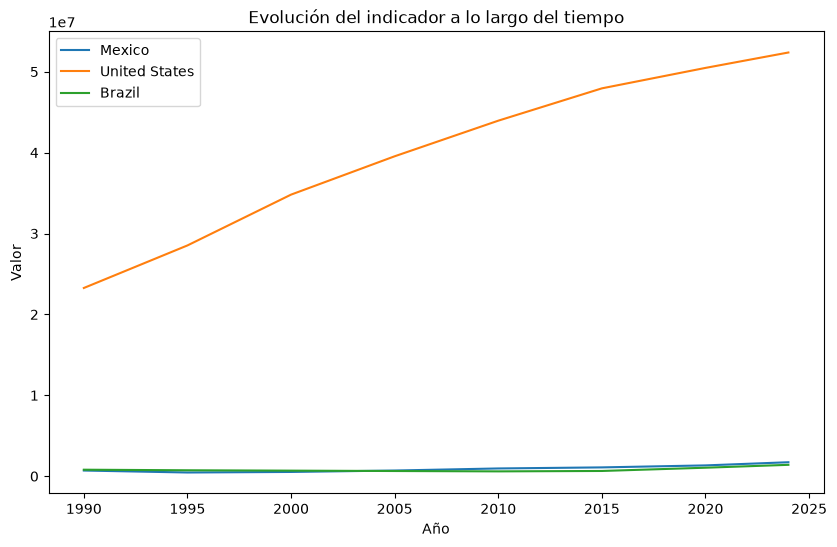

In [17]:
# Pregunta 8
# Tu codigo aqui
paises_3 = ["Mexico", "United States", "Brazil"]  # ajusta a tu gusto

plt.figure(figsize=(10,6))
for pais in paises_3:
    df_temp = df_paises[df_paises["entity"] == pais].sort_values("year")
    plt.plot(df_temp["year"], df_temp["valor"], label=pais)

plt.title("Evolución del indicador a lo largo del tiempo")
plt.xlabel("Año")
plt.ylabel("Valor")
plt.legend()
plt.show()

**Interpretación:**
Estados Unidos muestra un crecimiento sostenido y muy pronunciado en su número de inmigrantes internacionales, pasando de cerca de 23 millones en 1990 a más de 52 millones en 2024. En contraste, México y Brasil se mantienen con valores mucho más bajos y estables durante todo el periodo, con un crecimiento apenas perceptible. Esto refleja que Estados Unidos concentra una proporción enorme de la migración mundial en comparación con países como México y Brasil, que funcionan más como países de origen o tránsito migratorio que como destino final.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

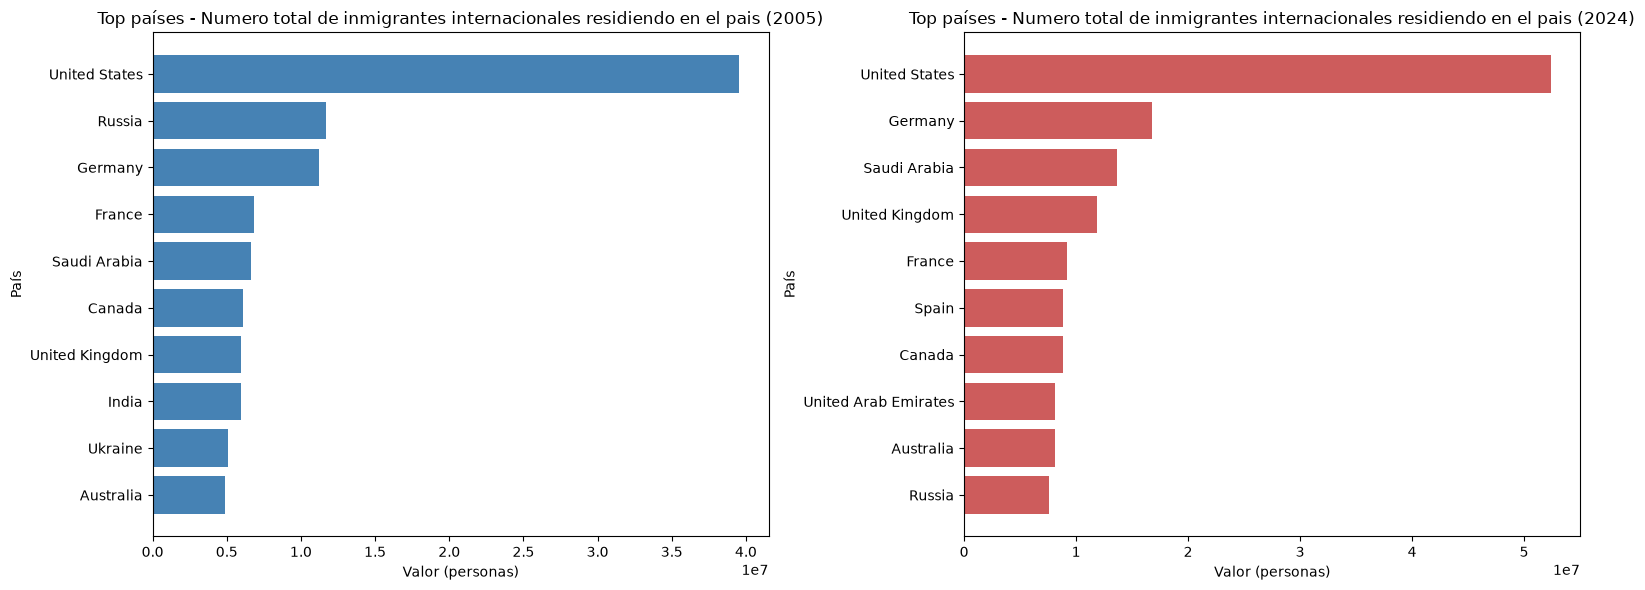

In [18]:
# Pregunta 9
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_nacimiento = 2005
anio_2023 = 2023

# Top 10 para el año de nacimiento
top_nacimiento = (
    df_paises[df_paises['year'] == anio_nacimiento]
    .sort_values('valor', ascending=False)
    .head(10)
)

anio_2023 = df_paises['year'].max()

top_2023 = (
    df_paises[df_paises['year'] == anio_2023]
    .sort_values('valor', ascending=False)
    .head(10)
)

# Gráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_nacimiento['entity'], top_nacimiento['valor'], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_xlabel(f"Valor ({config['unidad']})")
axes[0].set_ylabel("País")
axes[0].set_title(f"Top países - {config['descripcion']} ({anio_nacimiento})")

axes[1].barh(top_2023['entity'], top_2023['valor'], color='indianred')
axes[1].invert_yaxis()
axes[1].set_xlabel(f"Valor ({config['unidad']})")
axes[1].set_ylabel("País")
axes[1].set_title(f"Top países - {config['descripcion']} ({anio_2023})")

plt.tight_layout()
plt.show()

**Interpretación:**

Estados Unidos se mantuvo como el país con más inmigrantes en ambos años, mientras que Rusia bajó del top 10 y aparecieron nuevos países como España y Emiratos Árabes Unidos en 2024, mostrando cambios en los principales destinos migratorios del mundo.


## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

para concluir, a lo largo de este análisis que estuve haciendo con el dataset sobre migración. Encontré que columnas como code y owid_region tenían valores nulos, lo cual tiene sentido porque no aplican igual para entidades que representan agrupaciones (como continentes o "World") en vez de países individuales. Por eso fue importante filtrar bien usando la columna indicada en la configuración antes de analizar los datos. Una limitación clara del dataset es que maneja valores absolutos de migrantes, sin normalizar por población, lo que hace que los países más grandes siempre aparezcan en los primeros lugares del ranking sin que eso refleje una proporción real más alta. También hay huecos de información en ciertos años y países, lo que limita esas comparaciones directas. En mi opinion normalizaría los valores por población y profundizaría en las causas detrás de los cambios más grandes encontrados. Pero en general, pude mejorar y aprender sobre como limpiar y filtrar bien los datos es tan importante como saber interpretarlos.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
